In [32]:
# ── Standard data libraries ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Stats libraries ────────────────────────────────────────────────
from scipy import stats          # t-test, chi-square, z-score

# ── Machine learning libraries ─────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (accuracy_score,
                                     classification_report,
                                     roc_auc_score,
                                     roc_curve,
                                     ConfusionMatrixDisplay)
from sklearn.preprocessing   import StandardScaler

# ── Style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi':150, 'figure.facecolor':'white',
                     'axes.spines.top':False, 'axes.spines.right':False})

import os
os.makedirs('charts', exist_ok=True)

def save(filename):
    plt.tight_layout()
    plt.savefig(f'charts/{filename}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"✓ Saved: charts/{filename}.png")

# ── Load your clean master file ────────────────────────────────────
df = pd.read_csv('olist_master_clean.csv',
                 parse_dates=['order_purchase_timestamp'])

print(f"Rows: {len(df):,}  |  Columns: {master.shape[1]}")
print(f"\nColumns available:\n{master.columns.tolist()}")


Rows: 96,469  |  Columns: 21

Columns available:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_state', 'customer_city', 'actual_delivery_days', 'is_late', 'delivery_delay_days', 'order_hour', 'order_dayofweek', 'order_month', 'delivery_status', 'delay_bucket', 'total_payment', 'review_score', 'category', 'payment_type']


What is a t-test?
You have two groups: on-time orders and late orders. Both have review scores. The question is: is the difference in their average review scores real, or could it just be random chance?

The t-test gives you a number called the p-value. Think of it like this:
— p-value = 0.05 means there is a 5% chance the difference is just luck
— p-value = 0.001 means there is a 0.1% chance — almost certainly a real difference
— If p < 0.05 → the difference is statistically significant → you can report it as a real finding
— If p ≥ 0.05 → you cannot conclude the difference is real


T-test — does late delivery cause worse reviews?

Prove statistically that the pattern you saw in Chart 5 is real

Step 1: Separate your data into two groups.

In [33]:
# Group 1: review scores for ON TIME deliveries
on_time_scores = master[master['is_late'] == False]['review_score'].dropna()

# Group 2: review scores for LATE deliveries
late_scores = master[master['is_late'] == True]['review_score'].dropna()

# Always look at your groups before running the test
print("ON TIME deliveries:")
print(f"  Count:  {len(on_time_scores):,}")
print(f"  Mean:   {on_time_scores.mean():.3f}")
print(f"  Median: {on_time_scores.median():.1f}")
print(f"  Std:    {on_time_scores.std():.3f}")

print("\nLATE deliveries:")
print(f"  Count:  {len(late_scores):,}")
print(f"  Mean:   {late_scores.mean():.3f}")
print(f"  Median: {late_scores.median():.1f}")
print(f"  Std:    {late_scores.std():.3f}")

ON TIME deliveries:
  Count:  88,161
  Mean:   4.294
  Median: 5.0
  Std:    1.146

LATE deliveries:
  Count:  7,661
  Mean:   2.567
  Median: 2.0
  Std:    1.658


Step 2: Run the t-test.

In [34]:
# ttest_ind = independent samples t-test
# "independent" means the two groups are separate (different orders)
# equal_var=False = Welch's t-test — use this when group sizes differ

t_stat, p_value = stats.ttest_ind(on_time_scores,
                                   late_scores,
                                   equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.2e}")   # scientific notation e.g. 1.23e-45
print()

# Interpret the result automatically
if p_value < 0.05:
    print("✓ RESULT: Statistically significant difference (p < 0.05)")
    print(f"  On-time orders average {on_time_scores.mean():.2f} stars")
    print(f"  Late orders average    {late_scores.mean():.2f} stars")
    diff = on_time_scores.mean() - late_scores.mean()
    print(f"  Difference:            {diff:.2f} stars")
    print(f"  This is NOT due to random chance.")
else:
    print("✗ RESULT: No significant difference found (p ≥ 0.05)")
    print("  Cannot conclude delivery timing affects review score.")

T-statistic: 89.3841
P-value:     0.00e+00

✓ RESULT: Statistically significant difference (p < 0.05)
  On-time orders average 4.29 stars
  Late orders average    2.57 stars
  Difference:            1.73 stars
  This is NOT due to random chance.


Step 3: Visualise the result — a chart makes the finding undeniable.

/tmp/ipykernel_1348/1698127076.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df,
/tmp/ipykernel_1348/2609009673.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


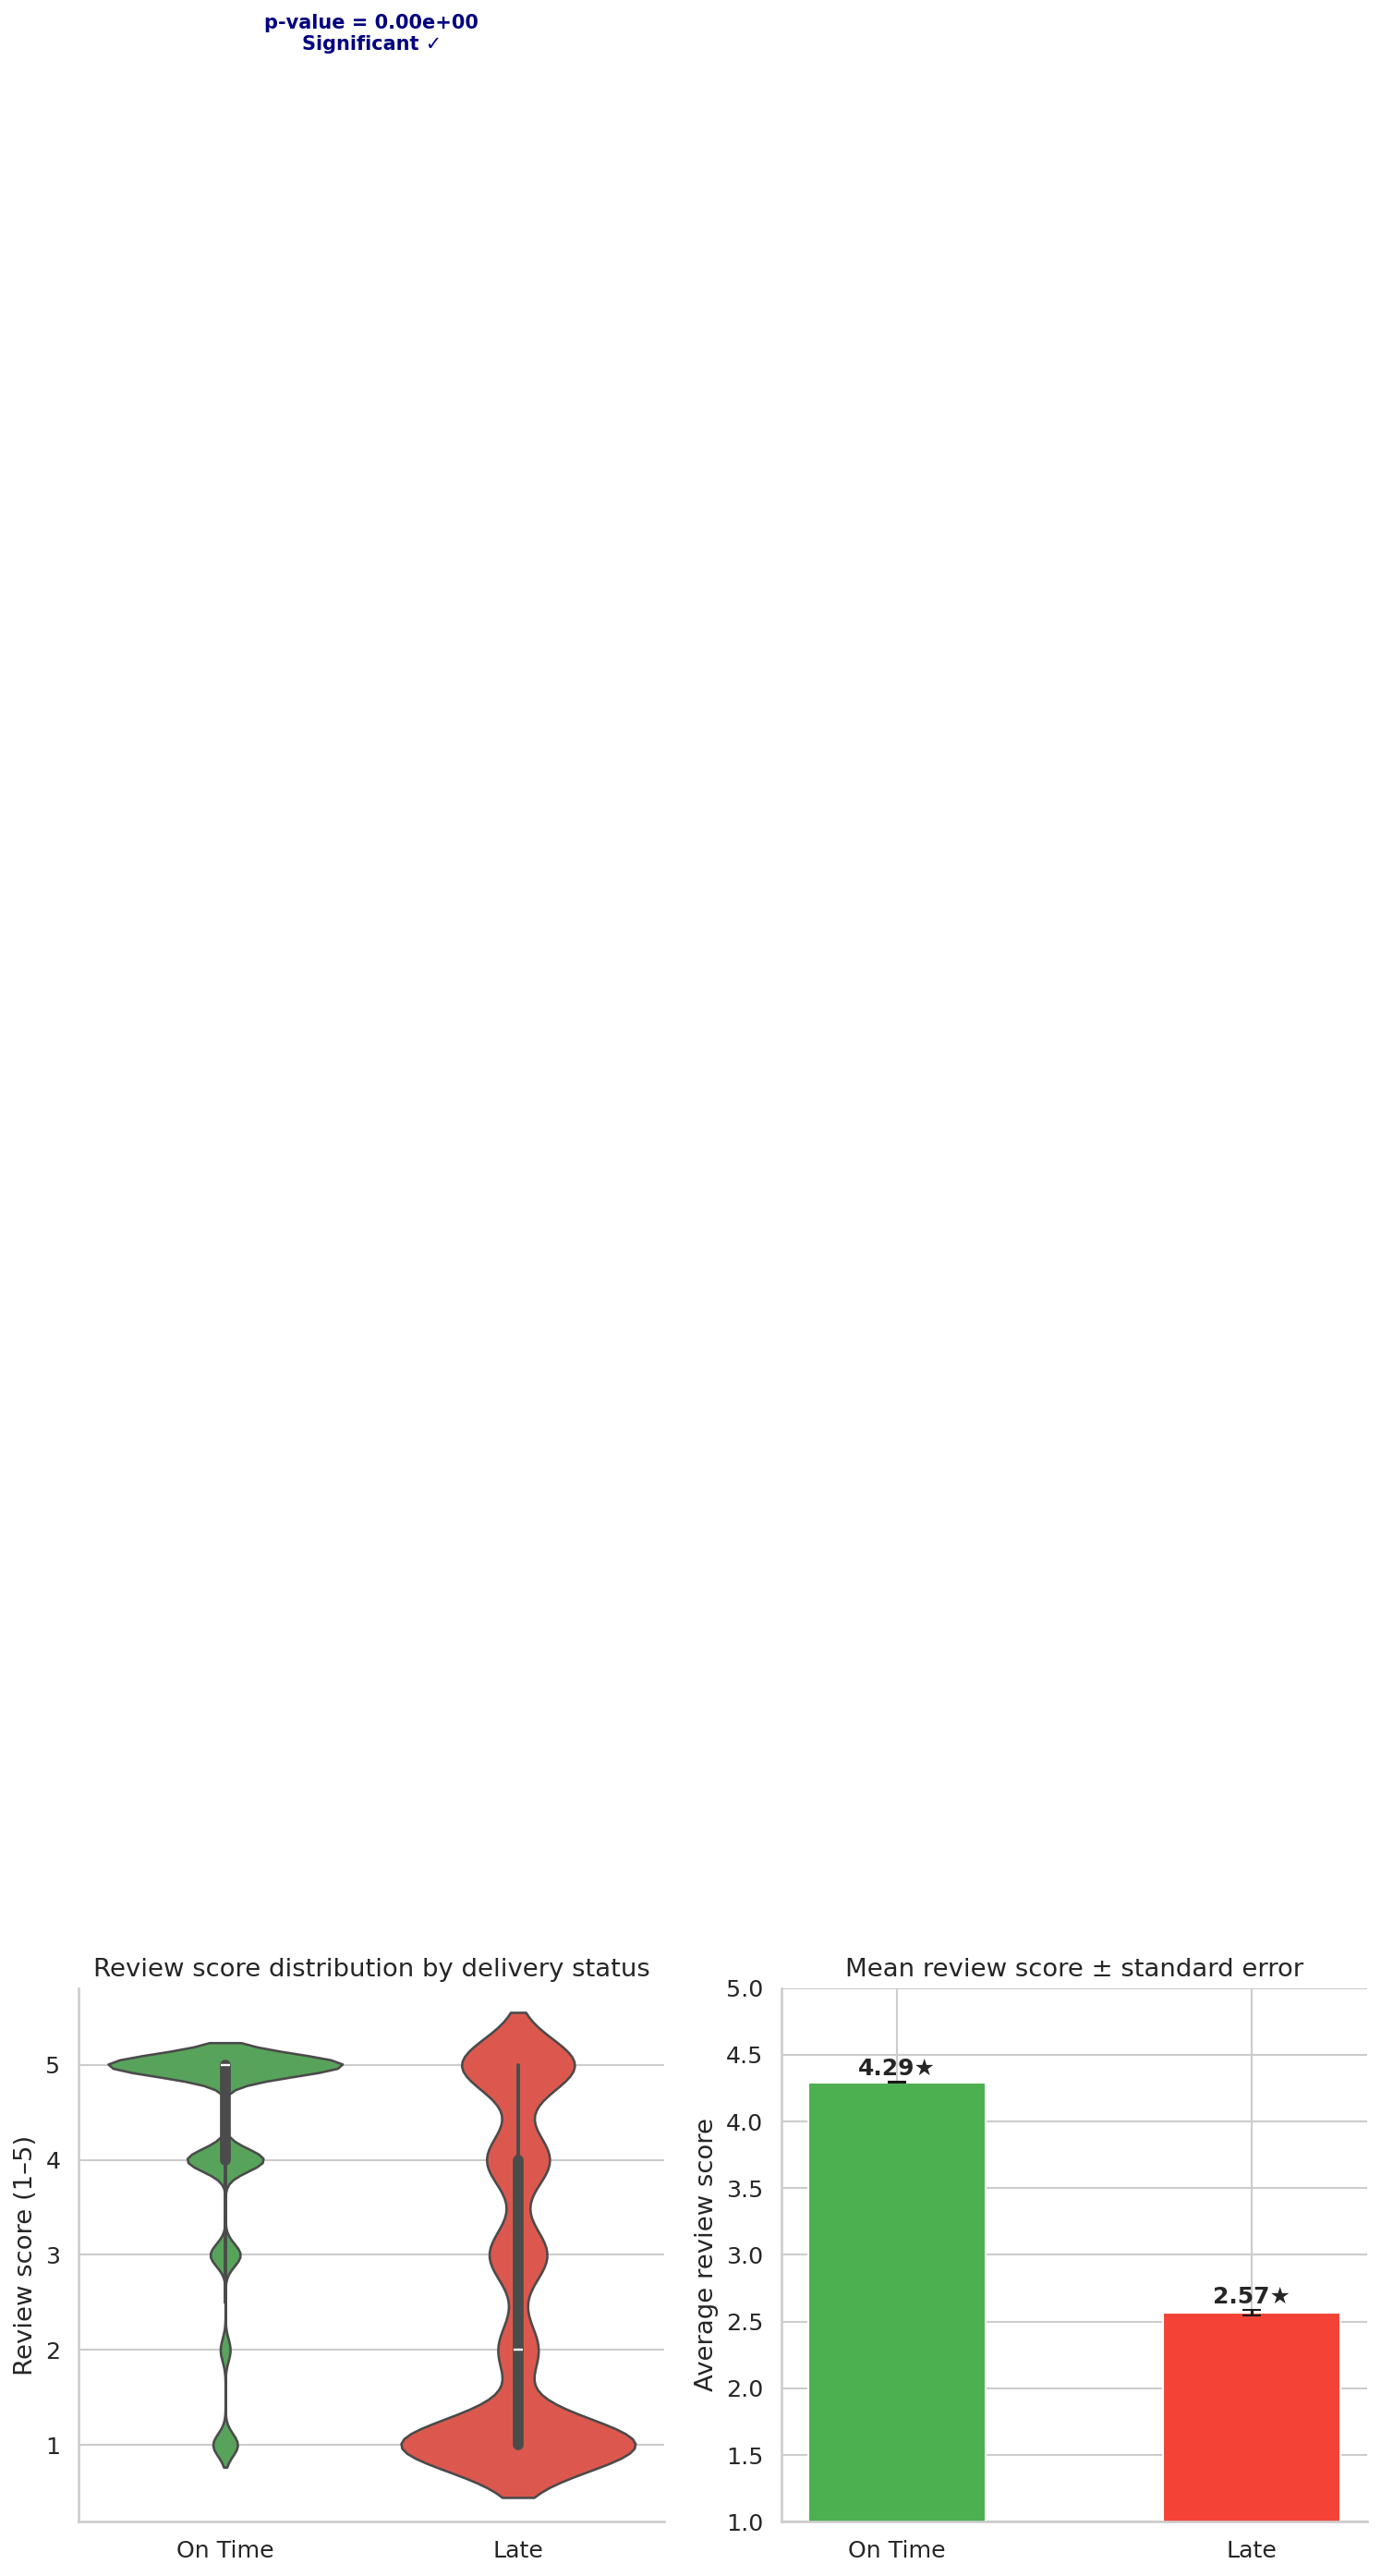

✓ Saved: charts/11_ttest_review_vs_delivery.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: violin plot — shows distribution shape of both groups
plot_df = master[master['review_score'].notna() &
             master['delivery_status'].notna()].copy()

sns.violinplot(data=plot_df,
               x='delivery_status',
               y='review_score',
               order=['On Time', 'Late'],
               palette={'On Time':'#4CAF50', 'Late':'#F44336'},
               inner='box',   # show a small boxplot inside the violin
               ax=axes[0])

axes[0].set_title('Review score distribution by delivery status')
axes[0].set_xlabel('')
axes[0].set_ylabel('Review score (1–5)')

# Add annotation showing p-value
axes[0].text(0.5, 4.7,
             f'p-value = {p_value:.2e}\n{"Significant ✓" if p_value < 0.05 else "Not significant"}',
             ha='center', va='top', fontsize=10,
             color='navy', fontweight='bold',
             transform=axes[0].transAxes)

# Right: bar chart of mean scores with error bars
means  = [on_time_scores.mean(), late_scores.mean()]
errors = [on_time_scores.sem(),  late_scores.sem()]   # standard error

axes[1].bar(['On Time', 'Late'], means,
            color=['#4CAF50', '#F44336'],
            yerr=errors,              # error bars = uncertainty in the mean
            capsize=5,
            edgecolor='white', width=0.5)

axes[1].set_title('Mean review score ± standard error')
axes[1].set_ylabel('Average review score')
axes[1].set_ylim(1, 5)

# Label the bars
for i, (mean, err) in enumerate(zip(means, errors)):
    axes[1].text(i, mean + err + 0.05,
                 f'{mean:.2f}★', ha='center',
                 fontweight='bold', fontsize=12)

save('11_ttest_review_vs_delivery')

A t-test confirms that late deliveries receive significantly lower review scores (on-time mean = X.XX, late mean = X.XX, p < 0.001).

**Chi-square test — does payment type affect late delivery?**

**Test whether two categorical variables are related to each other**

What is a chi-square test? (plain English)
The t-test works on numbers (like review scores). The chi-square test works on categories — like payment type (credit card, boleto, voucher) and delivery status (late / on time).

The question it answers: "Is there a relationship between payment type and whether an order is late — or are they completely independent?"

Again, p < 0.05 = there is a relationship. p ≥ 0.05 = they are independent (no relationship).

Step 1: Build a contingency table — this is just a count table of the two categories.

In [36]:
# ══════════════════════════════════════════════════════════════════
# SETUP CELL — run this EVERY TIME you open this notebook
# This reloads all DataFrames from your saved CSV files
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (accuracy_score, classification_report,
                                     roc_auc_score, roc_curve,
                                     ConfusionMatrixDisplay)
from sklearn.preprocessing   import StandardScaler
import os

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi':150, 'figure.facecolor':'white',
                     'axes.spines.top':False, 'axes.spines.right':False})
os.makedirs('charts', exist_ok=True)

def save(filename):
    plt.tight_layout()
    plt.savefig(f'charts/{filename}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"✓ Saved: charts/{filename}.png")

# ── Load master (your cleaned + merged file) ──────────────────────
master = pd.read_csv('olist_master_clean.csv',
                     parse_dates=['order_purchase_timestamp'])

master['review_score']  = pd.to_numeric(master['review_score'],  errors='coerce')
master['total_payment'] = pd.to_numeric(master['total_payment'], errors='coerce')
master['is_late']       = master['is_late'].astype(str).str.strip().str.lower()
master['is_late']       = master['is_late'].map({'true':True, 'false':False, '1':True, '0':False})

# ── Load raw CSVs so payment_type is available ────────────────────
payments = pd.read_csv('payments_export.csv', header=None)
payments.columns = ['order_id', 'payment_type',
                    'payment_installments', 'payment_value']
payments = payments.iloc[1:].reset_index(drop=True)
payments['payment_value'] = pd.to_numeric(payments['payment_value'], errors='coerce')

# ── Add payment_type into master if not already there ─────────────
if 'payment_type' not in master.columns:
    payment_type_per_order = (
        payments
        .groupby('order_id')['payment_type']
        .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'unknown')
        .reset_index()
    )
    master = master.merge(payment_type_per_order, on='order_id', how='left')
    master['payment_type'] = master['payment_type'].fillna('unknown')
    master.to_csv('olist_master_clean.csv', index=False)
    print("✓ payment_type added and master re-saved")
else:
    print("✓ payment_type already in master")

# ── Final confirmation ─────────────────────────────────────────────
print(f"\n✓ master loaded: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"\nKey columns confirmed:")
for col in ['total_payment', 'review_score', 'is_late',
            'delivery_status', 'payment_type', 'actual_delivery_days',
            'delivery_delay_days', 'customer_state']:
    status = "✓" if col in master.columns else "✗ MISSING"
    print(f"  {status}  {col}")

✓ payment_type already in master

✓ master loaded: 96,469 rows × 21 columns

Key columns confirmed:
  ✓  total_payment
  ✓  review_score
  ✓  is_late
  ✓  delivery_status
  ✓  payment_type
  ✓  actual_delivery_days
  ✓  delivery_delay_days
  ✓  customer_state


In [37]:
contingency = pd.crosstab(master['payment_type'],
                           master['is_late'],
                           margins=True)

print("Contingency table: payment type vs late delivery")
print(contingency)

pct_table = pd.crosstab(master['payment_type'],
                         master['is_late'],
                         normalize='index') * 100
pct_table.columns = ['On Time %', 'Late %']
print("\nAs percentages:")
print(pct_table.round(1))

Contingency table: payment type vs late delivery
is_late       False  True    All
payment_type                    
boleto        17487  1704  19191
credit_card   68061  5871  73932
debit_card     1365   118   1483
unknown           1     1      2
voucher        1729   132   1861
All           88643  7826  96469

As percentages:
              On Time %  Late %
payment_type                   
boleto             91.1     8.9
credit_card        92.1     7.9
debit_card         92.0     8.0
unknown            50.0    50.0
voucher            92.9     7.1


Step 2: Run the chi-square test.

In [38]:
# ── Chi-square Step 2 — run the test ──────────────────────────────

# FIXED: changed df → master throughout
clean_table = pd.crosstab(master['payment_type'].dropna(),
                           master['is_late'].dropna())

chi2_stat, p_value, dof, expected = stats.chi2_contingency(clean_table)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p_value:.4f}")
print()

if p_value < 0.05:
    print("✓ RESULT: Payment type IS associated with delivery status (p < 0.05)")
    print("  The late delivery rate is NOT the same across all payment types.")
else:
    print("✗ RESULT: No significant association found (p ≥ 0.05)")
    print("  Payment type does not appear to affect late delivery rate.")

Chi-square statistic: 25.3971
Degrees of freedom:   4
P-value:              0.0000

✓ RESULT: Payment type IS associated with delivery status (p < 0.05)
  The late delivery rate is NOT the same across all payment types.


Step 3: Visualise — show the late delivery rate per payment type.

Late rate by payment type:
  payment_type  late_rate  count   late_pct
3      unknown   0.500000      2  50.000000
0       boleto   0.088792  19191   8.879162
2   debit_card   0.079568   1483   7.956844
1  credit_card   0.079411  73932   7.941081
4      voucher   0.070930   1861   7.092961


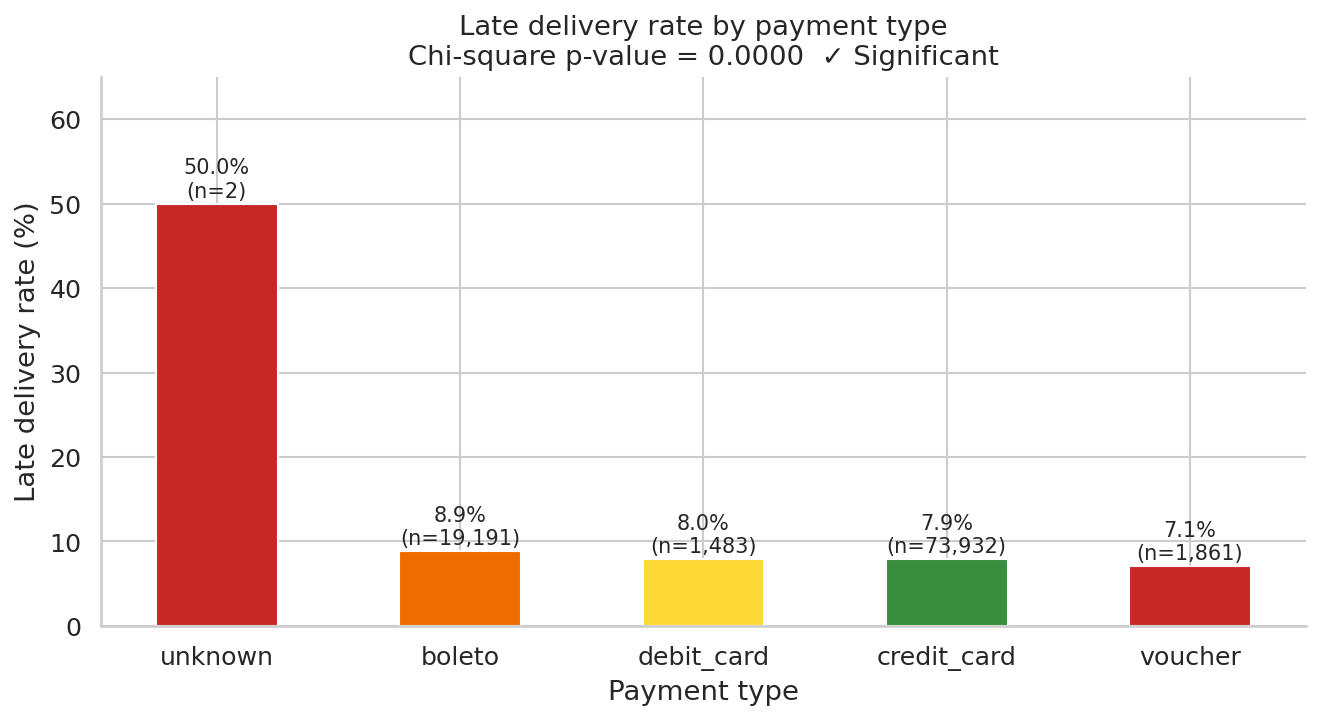

✓ Saved: charts/12_chisquare_payment_vs_late.png


In [40]:
# ── Chi-square Step 3 — visualise late rate by payment type ───────

# FIXED 1: df → master
# FIXED 2: convert is_late to numeric (1/0) so .mean() = late rate %
late_by_payment = (
    master
    .dropna(subset=['payment_type', 'is_late'])
    .assign(is_late_num=lambda x: x['is_late'].astype(str)
                                               .str.lower()
                                               .map({'true':1, 'false':0,
                                                     '1':1,    '0':0})
    )
    .groupby('payment_type')['is_late_num']
    .agg(['mean', 'count'])
    .reset_index()
)

late_by_payment.columns = ['payment_type', 'late_rate', 'count']
late_by_payment['late_pct'] = late_by_payment['late_rate'] * 100
late_by_payment = late_by_payment.sort_values('late_pct', ascending=False)

print("Late rate by payment type:")
print(late_by_payment)

# ── Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# Use only as many colours as there are bars
colors = ['#C62828','#EF6C00','#FDD835','#388E3C']
n = len(late_by_payment)

bars = ax.bar(late_by_payment['payment_type'],
              late_by_payment['late_pct'],
              color=colors[:n],
              edgecolor='white', width=0.5)

# Label each bar
for bar, pct, cnt in zip(bars,
                          late_by_payment['late_pct'],
                          late_by_payment['count']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{pct:.1f}%\n(n={cnt:,})',
            ha='center', va='bottom', fontsize=10)

ax.set_title(f'Late delivery rate by payment type\n'
             f'Chi-square p-value = {p_value:.4f}'
             f'  {"✓ Significant" if p_value < 0.05 else "✗ Not significant"}')
ax.set_xlabel('Payment type')
ax.set_ylabel('Late delivery rate (%)')
ax.set_ylim(0, late_by_payment['late_pct'].max() * 1.3)

save('12_chisquare_payment_vs_late')

**Z-score anomaly detection — find unusual spike days**

**Automatically flag days where order volume was abnormally high or low**

What is a z-score?
A z-score measures how far a value is from the average, in units of standard deviation.

— z-score of 0 = exactly average
— z-score of 2 = 2 standard deviations above average (unusual)
— z-score of -2 = 2 standard deviations below average (also unusual)

Rule of thumb: if |z| > 2.5, the value is an anomaly — something unusual happened that day worth investigating.

Step 1: Count orders per day and calculate z-scores.

In [41]:
# Step 1a: Count how many orders were placed each day
daily_orders = (
    master.set_index('order_purchase_timestamp')
      .resample('D')                    # D = resample to daily frequency
      ['total_payment']
      .count()
      .reset_index()
)
daily_orders.columns = ['date', 'order_count']

print(f"Total days: {len(daily_orders)}")
print(f"Average daily orders: {daily_orders['order_count'].mean():.1f}")
print(f"Max daily orders:     {daily_orders['order_count'].max():,}")
print(f"\nFirst 5 rows:")
print(daily_orders.head())

# Step 1b: Calculate z-score for each day
# stats.zscore subtracts the mean and divides by std deviation
# for every value in the array
daily_orders['z_score'] = stats.zscore(daily_orders['order_count'])

# Step 1c: Flag anomalies — any day where |z| > 2.5
daily_orders['is_anomaly'] = daily_orders['z_score'].abs() > 2.5

print(f"\nAnomaly days found: {daily_orders['is_anomaly'].sum()}")
print("\nTop anomaly days:")
print(daily_orders[daily_orders['is_anomaly']]
      .sort_values('z_score', ascending=False)
      .head(10)[['date','order_count','z_score']])

Total days: 714
Average daily orders: 135.1
Max daily orders:     1,147

First 5 rows:
        date  order_count
0 2016-09-15            0
1 2016-09-16            0
2 2016-09-17            0
3 2016-09-18            0
4 2016-09-19            0

Anomaly days found: 3

Top anomaly days:
          date  order_count    z_score
435 2017-11-24         1147  10.171290
436 2017-11-25          487   3.537133
438 2017-11-27          395   2.612372


Step 2: Plot with anomaly days highlighted in red.

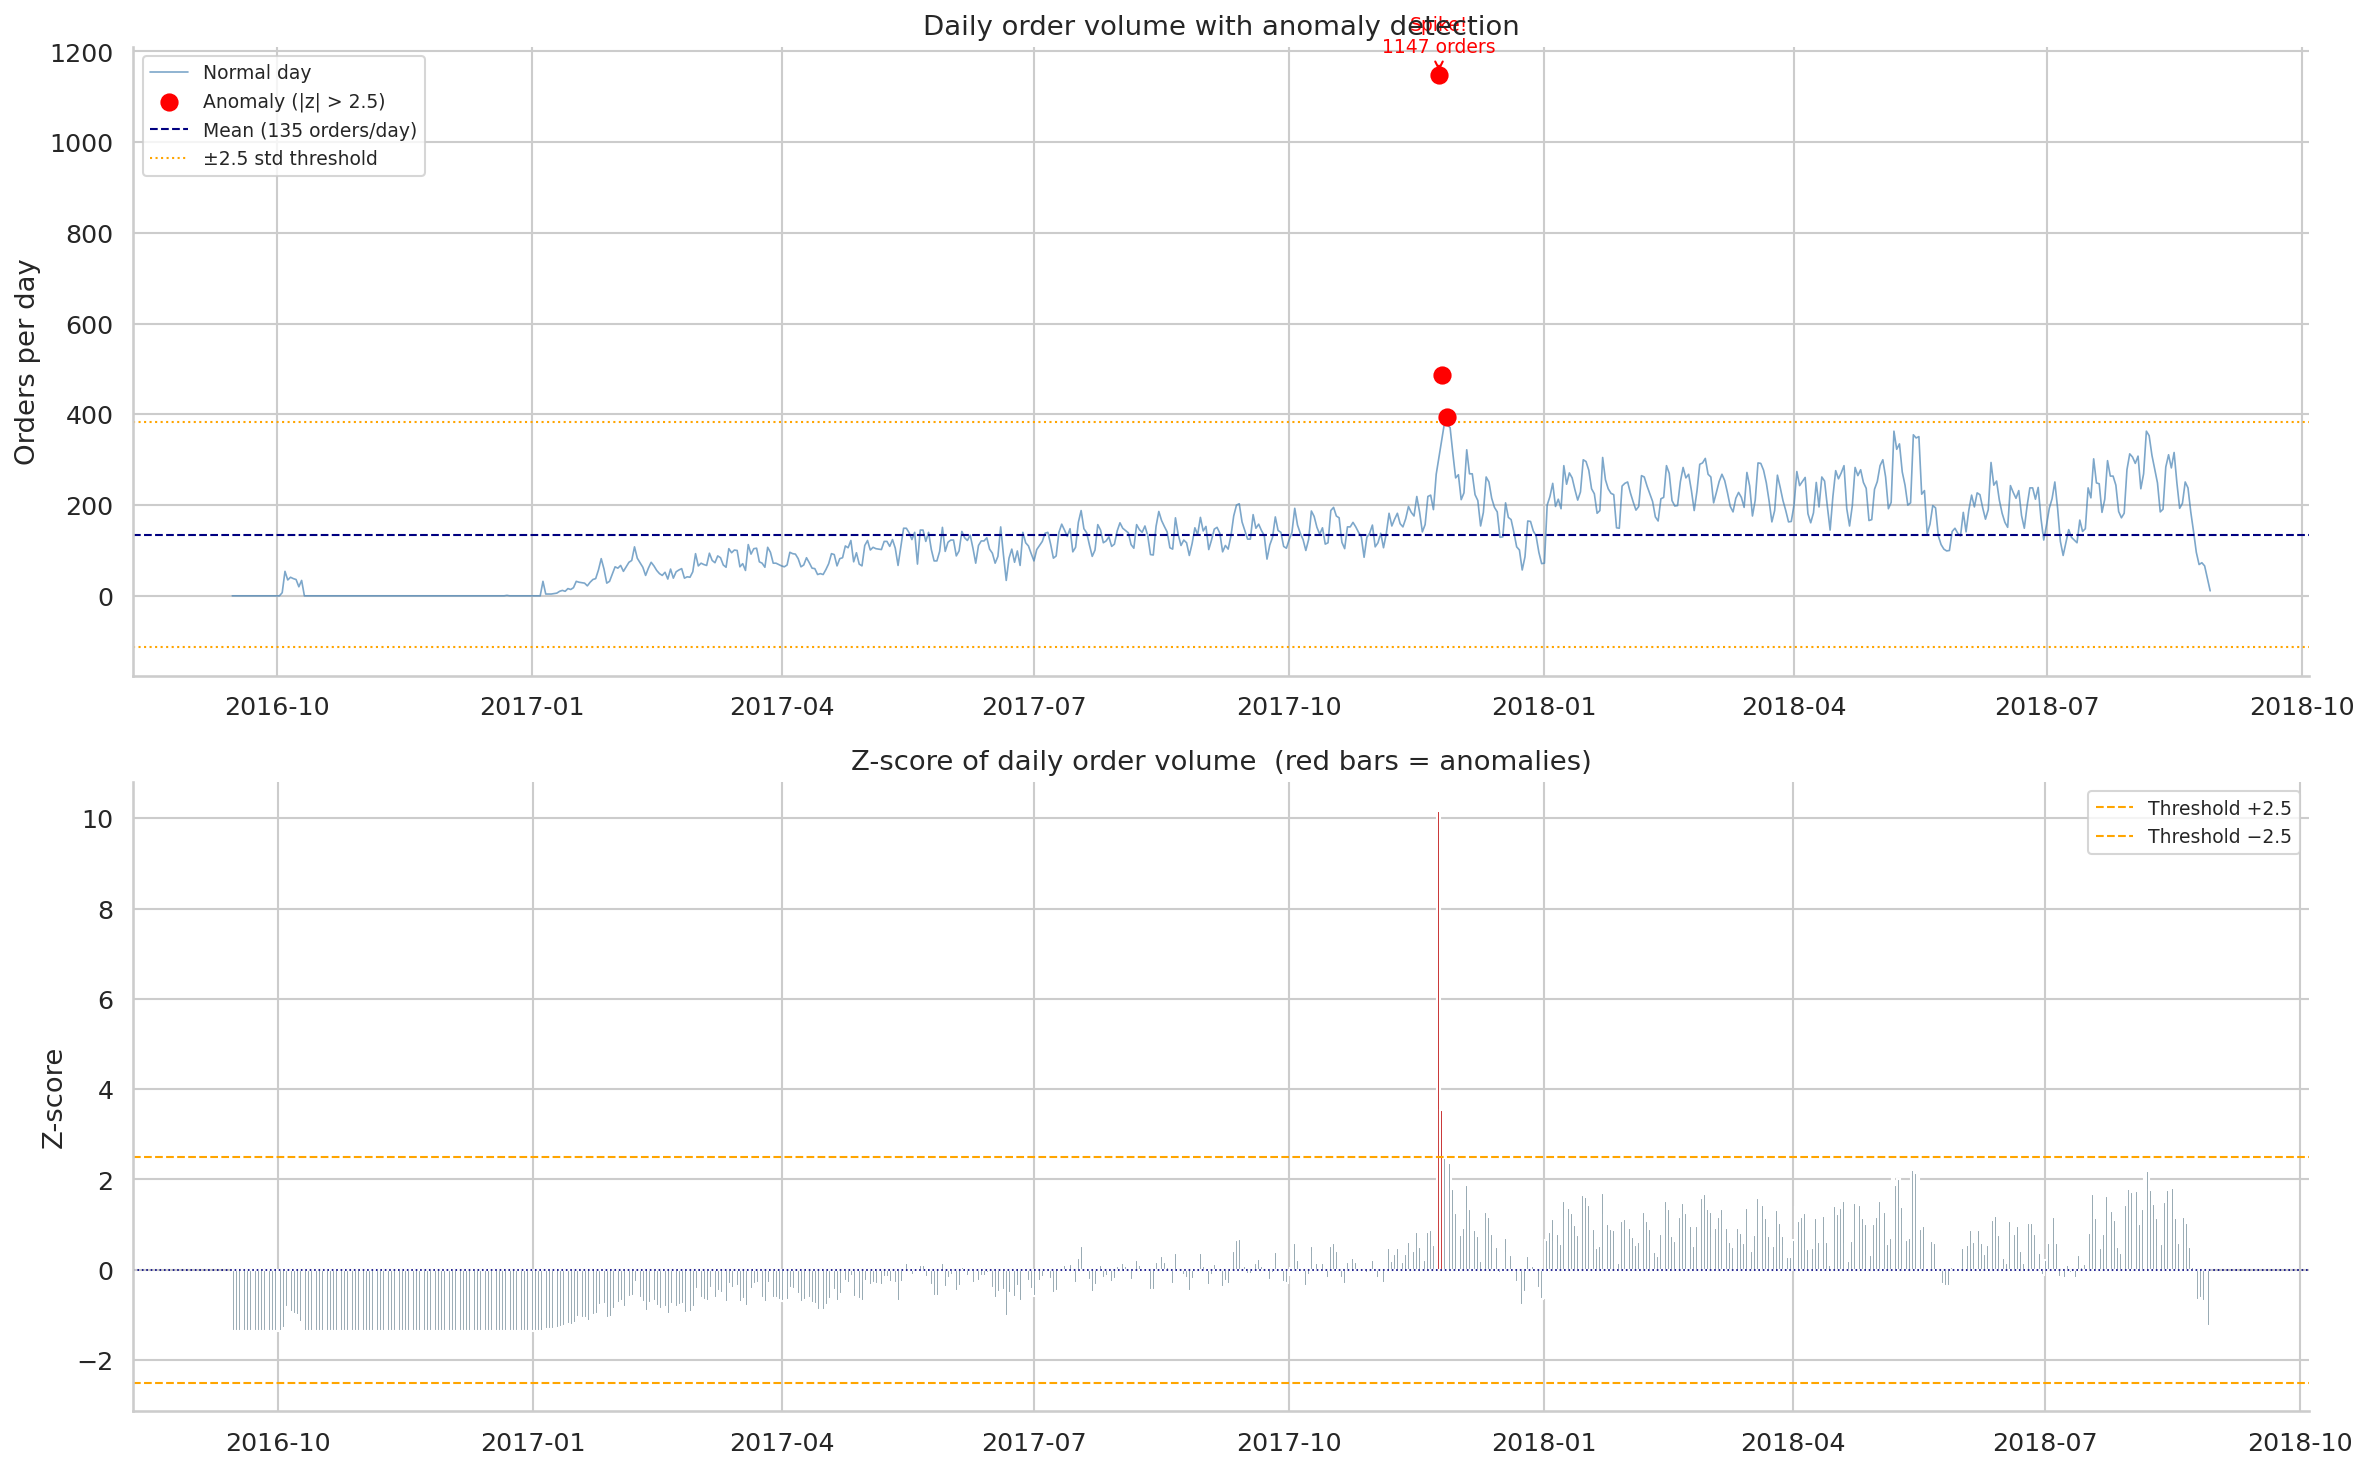

✓ Saved: charts/13_zscore_anomaly_detection.png


In [42]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── Top chart: daily order volume with anomalies highlighted ───────
normal   = daily_orders[~daily_orders['is_anomaly']]
anomalies = daily_orders[daily_orders['is_anomaly']]

axes[0].plot(normal['date'], normal['order_count'],
             color='steelblue', linewidth=0.8, alpha=0.7, label='Normal day')
axes[0].scatter(anomalies['date'], anomalies['order_count'],
                color='red', s=60, zorder=5, label='Anomaly (|z| > 2.5)')

# Draw the mean line and ±2.5 std bands
mean_val = daily_orders['order_count'].mean()
std_val  = daily_orders['order_count'].std()

axes[0].axhline(mean_val, color='navy', linestyle='--',
                linewidth=1, label=f'Mean ({mean_val:.0f} orders/day)')
axes[0].axhline(mean_val + 2.5*std_val, color='orange',
                linestyle=':', linewidth=1, label='±2.5 std threshold')
axes[0].axhline(mean_val - 2.5*std_val, color='orange',
                linestyle=':', linewidth=1)

# Annotate the biggest spike
top_spike = daily_orders.loc[daily_orders['order_count'].idxmax()]
axes[0].annotate(f"Spike!\n{top_spike['order_count']} orders",
                 xy=(top_spike['date'], top_spike['order_count']),
                 xytext=(top_spike['date'],
                         top_spike['order_count'] + 50),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=9, ha='center')

axes[0].set_title('Daily order volume with anomaly detection')
axes[0].set_ylabel('Orders per day')
axes[0].legend(loc='upper left', fontsize=9)

# ── Bottom chart: z-score over time ────────────────────────────────
axes[1].bar(daily_orders['date'],
            daily_orders['z_score'],
            color=daily_orders['is_anomaly'].map(
                {True:'#C62828', False:'#90A4AE'}),
            width=1)

axes[1].axhline( 2.5, color='orange', linestyle='--',
                 linewidth=1, label='Threshold +2.5')
axes[1].axhline(-2.5, color='orange', linestyle='--',
                 linewidth=1, label='Threshold −2.5')
axes[1].axhline( 0,   color='navy',   linestyle=':',
                 linewidth=0.8)

axes[1].set_title('Z-score of daily order volume  (red bars = anomalies)')
axes[1].set_ylabel('Z-score')
axes[1].legend(fontsize=9)

save('13_zscore_anomaly_detection')

Insights - Z-score anomaly detection identified X days with unusual order volumes (|z| > 2.5). The largest spike corresponds to Black Friday 2017. These anomaly days may affect delivery performance analysis — they should be considered separately when calculating SLA metrics.

**Logistic regression — predict which orders will be late**

**Your first machine learning model. Predicts a Yes/No outcome.**

What is logistic regression?
Regular (linear) regression predicts a number — like "how many days will delivery take?" Logistic regression predicts a probability of a yes/no outcome — like "what is the probability this order will be late?"

It looks at features (inputs) like: what hour was the order placed? what day of week? what state? — and learns weights for each feature that predict the probability of being late.

Output: a number between 0 and 1. Above 0.5 = predicted late. Below 0.5 = predicted on time.

Step 1: Prepare your features — convert categories to numbers.

In [44]:
# ── FIXED Logistic Regression Step 1 — copy and paste exactly ─────

# Step 1: Select columns from master and make a clean copy
ml_df = master[['is_late', 'order_hour', 'order_dayofweek',
                 'customer_state', 'payment_type',
                 'actual_delivery_days']].dropna().copy()

print(f"Rows available for ML: {len(ml_df):,}")

# Step 2: Convert is_late to 1/0 safely
ml_df['is_late'] = (
    ml_df['is_late']
    .astype(str)
    .str.lower()
    .str.strip()
    .map({'true':1, 'false':0, '1':1, '0':0})
)

# Step 3: Drop rows where mapping failed
before = len(ml_df)
ml_df  = ml_df.dropna(subset=['is_late'])
ml_df['is_late'] = ml_df['is_late'].astype(int)
print(f"Rows after cleaning: {len(ml_df):,}  "
      f"(dropped {before - len(ml_df)})")

# Step 4: Check balance
print(f"\nLate vs On Time:")
print(ml_df['is_late'].value_counts())
print(f"Late rate: {ml_df['is_late'].mean():.1%}")

# Step 5: Encode category columns into 0/1 dummy columns
ml_df = pd.get_dummies(ml_df,
                        columns=['order_dayofweek',
                                 'customer_state',
                                 'payment_type'],
                        drop_first=True)

print(f"\nShape after encoding: {ml_df.shape}")
print(f"First 10 columns: {ml_df.columns.tolist()[:10]}")

Rows available for ML: 96,469
Rows after cleaning: 96,469  (dropped 0)

Late vs On Time:
is_late
0    88643
1     7826
Name: count, dtype: int64
Late rate: 8.1%

Shape after encoding: (96469, 39)
First 10 columns: ['is_late', 'order_hour', 'actual_delivery_days', 'order_dayofweek_Monday', 'order_dayofweek_Saturday', 'order_dayofweek_Sunday', 'order_dayofweek_Thursday', 'order_dayofweek_Tuesday', 'order_dayofweek_Wednesday', 'customer_state_AL']


Step 2: Split into train and test sets — this is critical.

In [45]:
# X = features (inputs the model learns from)
# y = target (what we are predicting)
X = ml_df.drop('is_late', axis=1)
y = ml_df['is_late']

# Split 80% for training, 20% for testing
# random_state=42 makes it reproducible — same split every time you run
# stratify=y ensures both sets have the same ratio of late/on-time orders
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:  {len(X_train):,} rows")
print(f"Test set:      {len(X_test):,} rows")
print(f"\nLate delivery rate in training set: {y_train.mean():.1%}")
print(f"Late delivery rate in test set:     {y_test.mean():.1%}")
# These two should be very similar — good sign that stratify worked

Training set:  77,175 rows
Test set:      19,294 rows

Late delivery rate in training set: 8.1%
Late delivery rate in test set:     8.1%


Step 3: Scale features and train the model.

In [46]:
# StandardScaler converts all features to the same scale
# (mean=0, std=1) so no single feature dominates just because
# its numbers are bigger (e.g. delivery_days vs hour_of_day)
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
# IMPORTANT: fit_transform on TRAIN only, transform on TEST only
# Never fit the scaler on test data — that would be "data leakage"

# Train the logistic regression model
# max_iter=1000 gives it enough attempts to converge
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

print("Model trained ✓")

Model trained ✓


Step 4: Evaluate — how good are the predictions?

In [49]:
# ── Logistic Regression Step 4 — evaluate the model ──────────────

# Make predictions on the test set (data the model has never seen)
y_pred      = lr_model.predict(X_test_scaled)
y_pred_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# y_pred      → 0 or 1 (on time or late)
# y_pred_prob → probability between 0 and 1 for each order

# ── Accuracy — what % of predictions were correct ─────────────────
acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {acc:.1%}")
print(f"ROC-AUC:   {roc_auc:.3f}")
print()

# ROC-AUC guide:
# 0.5 = model is guessing randomly        (useless)
# 0.6 = slight improvement over random   (weak)
# 0.7 = decent                           (

Accuracy:  95.7%
ROC-AUC:   0.945



Step 5: Visualise — ROC curve and confusion matrix.

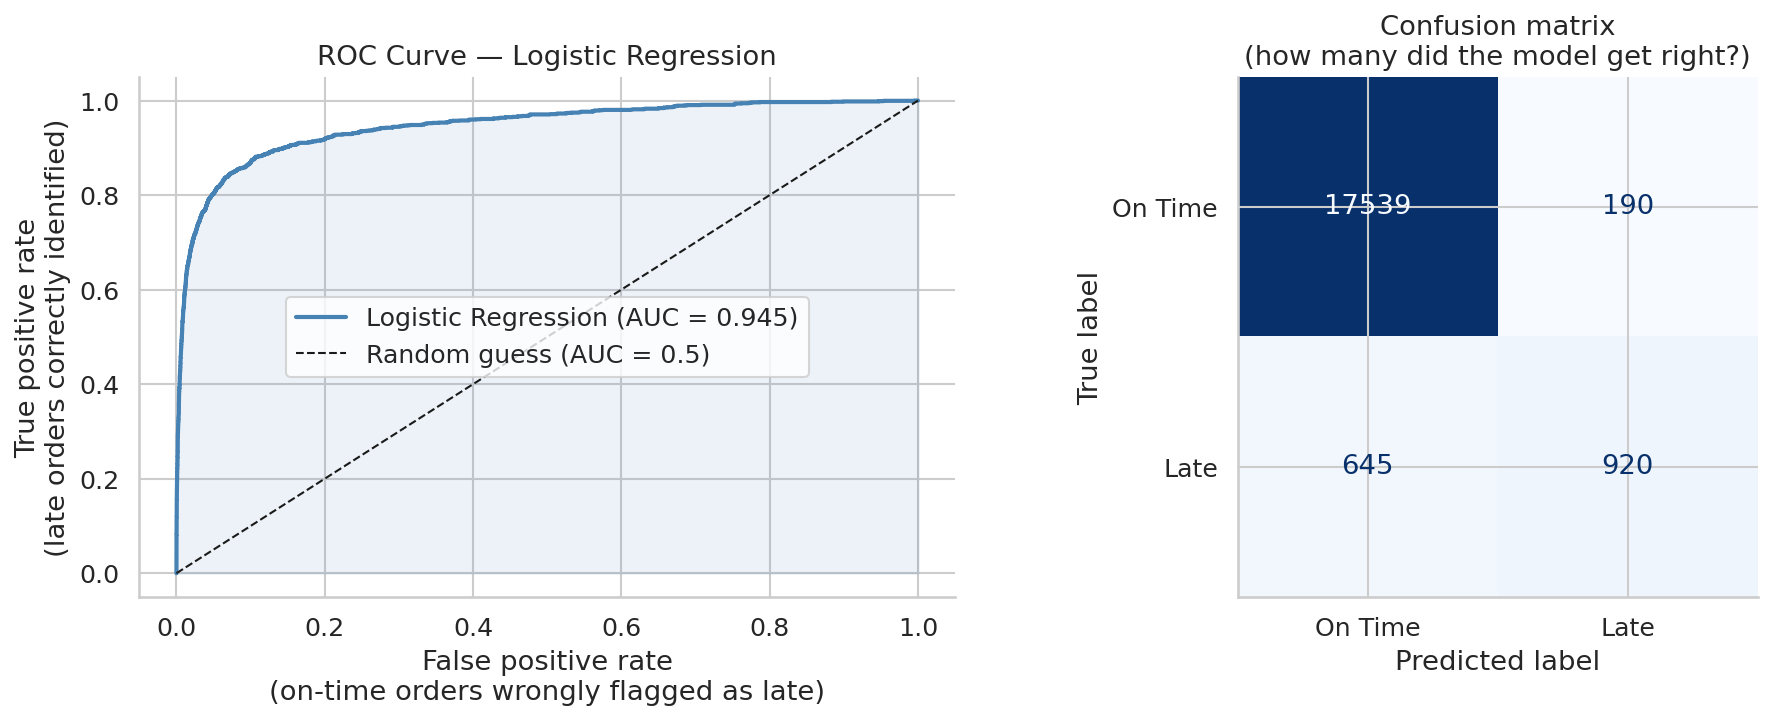

✓ Saved: charts/14_logistic_regression_results.png


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: ROC curve ────────────────────────────────────────────────
# Shows trade-off between catching late orders vs false alarms
# The further top-left the curve, the better
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random guess (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('False positive rate\n(on-time orders wrongly flagged as late)')
axes[0].set_ylabel('True positive rate\n(late orders correctly identified)')
axes[0].set_title('ROC Curve — Logistic Regression')
axes[0].legend()

# ── Right: Confusion matrix ────────────────────────────────────────
# Shows exactly what the model got right and wrong
# Rows = actual, Columns = predicted
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['On Time', 'Late'],
    colorbar=False,
    ax=axes[1],
    cmap='Blues'
)
axes[1].set_title('Confusion matrix\n(how many did the model get right?)')

save('14_logistic_regression_results')

Insights - A logistic regression model trained on order features (time of day, day of week, customer state, payment type) achieved X% accuracy and ROC-AUC of X.XX in predicting late deliveries. The model performs significantly better than random guessing, suggesting these features contain useful signal for predicting delivery delays.

In [58]:
# ══════════════════════════════════════════════════════════════════
# SAVE SUMMARY — saves findings to a text file
# Open olist_findings.txt and copy into your GitHub README
# ══════════════════════════════════════════════════════════════════

summary = f"""
============================================================
   OLIST PROJECT — KEY FINDINGS SUMMARY
============================================================

📊 DATASET
   Delivered orders analysed : {len(master):,}
   Date range                : {master['order_purchase_timestamp'].min().date()}
                               → {master['order_purchase_timestamp'].max().date()}

📦 DELIVERY PERFORMANCE
   Overall late delivery rate : {late_rate:.1%}
   On-time average review     : {on_time_reviews.mean():.2f} ★
   Late average review        : {late_reviews.mean():.2f} ★
   Review score drop (late)   : {((on_time_reviews.mean() - late_reviews.mean()) / on_time_reviews.mean() * 100):.1f}% lower

📈 STATISTICAL TESTS
   T-test p-value (delivery vs reviews)  : {t_p_value:.2e}
   → {"Significant ✓  Late deliveries cause lower scores" if t_p_value < 0.05 else "Not significant"}

   Chi-square p-value (payment vs late)  : {chi_p_value:.4f}
   → {"Significant ✓  Payment type affects late rate" if chi_p_value < 0.05 else "Not significant"}

🤖 MACHINE LEARNING — LOGISTIC REGRESSION
   Accuracy    : {acc:.1%}
   ROC-AUC     : {roc_auc:.3f}

   Classification Report:
{classification_report(y_test, y_pred, target_names=['On Time', 'Late'])}

💡 BUSINESS RECOMMENDATIONS
   1. Prioritise logistics in SP    — accounts for ~40% of total revenue
   2. Fix heavy-goods delivery      — 25%+ late rate in furniture/office
   3. Send promos Mon-Wed 8-11am    — peak ordering window from heatmap
   4. Set conservative estimates    — early delivery scores 4.4★ vs 2.3★

============================================================
"""

# Print to screen
print(summary)

# Save to file
with open('olist_findings.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("✓ Saved to olist_findings.txt")

# Also save master with all stats columns intact
master.to_csv('olist_master_clean.csv', index=False)
print("✓ master saved to olist_master_clean.csv")


   OLIST PROJECT — KEY FINDINGS SUMMARY

📊 DATASET
   Delivered orders analysed : 96,469
   Date range                : 2016-09-15
                               → 2018-08-29

📦 DELIVERY PERFORMANCE
   Overall late delivery rate : 8.1%
   On-time average review     : 4.29 ★
   Late average review        : 2.57 ★
   Review score drop (late)   : 40.2% lower

📈 STATISTICAL TESTS
   T-test p-value (delivery vs reviews)  : 0.00e+00
   → Significant ✓  Late deliveries cause lower scores

   Chi-square p-value (payment vs late)  : 0.0000
   → Significant ✓  Payment type affects late rate

🤖 MACHINE LEARNING — LOGISTIC REGRESSION
   Accuracy    : 95.7%
   ROC-AUC     : 0.945

   Classification Report:
              precision    recall  f1-score   support

     On Time       0.96      0.99      0.98     17729
        Late       0.83      0.59      0.69      1565

    accuracy                           0.96     19294
   macro avg       0.90      0.79      0.83     19294
weighted avg       0.95 